In [92]:
import pandas as pd

btc = pd.read_csv(
    "/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv"
)

# Update Close Time and Open Time columns if values are less than 2000000000000
btc["Close Time"] = btc["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
btc["Open Time"] = btc["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

In [93]:
# 将时间戳转换为 datetime 格式
btc["Close Time"] = pd.to_datetime(btc["Close Time"], unit="us")
btc["Open Time"] = pd.to_datetime(btc["Open Time"], unit="us")

# 设置索引
btc.set_index("Close Time", inplace=True)

In [94]:
btc = btc.loc["2024-01-01":"2024-07-01"]

In [95]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置图形风格
plt.style.use("seaborn-v0_8")

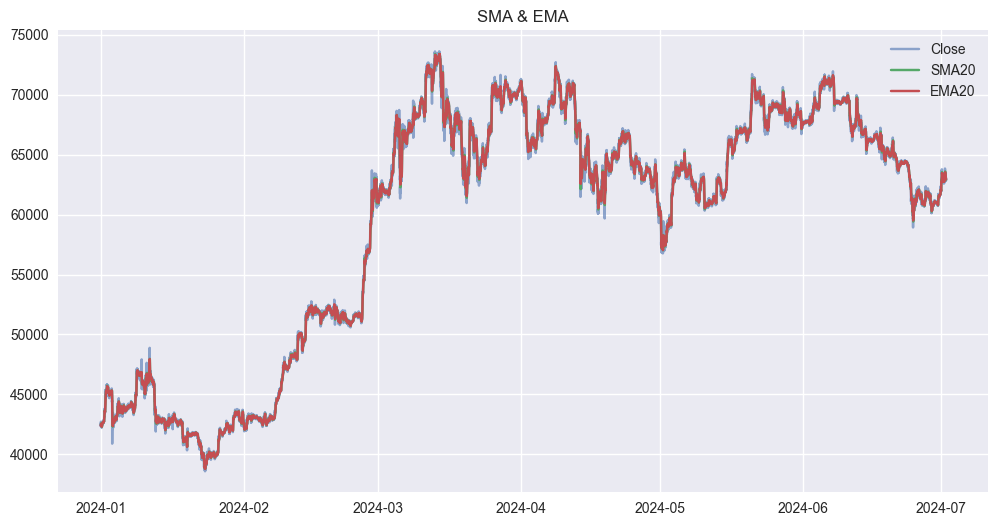

In [96]:
# SMA & EMA
btc["SMA20"] = btc["Close"].rolling(20).mean()
btc["EMA20"] = btc["Close"].ewm(span=20, adjust=False).mean()

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(btc["SMA20"], label="SMA20")
plt.plot(btc["EMA20"], label="EMA20")
plt.title("SMA & EMA")
plt.legend()
plt.show()

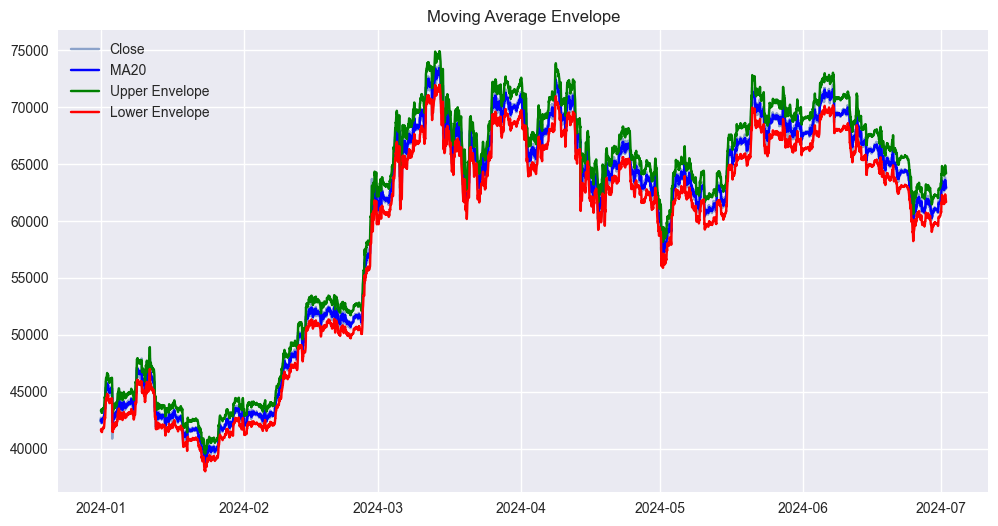

In [97]:
k = 0.02
ma = btc["Close"].rolling(20).mean()
btc["Env_Upper"] = ma * (1 + k)
btc["Env_Lower"] = ma * (1 - k)

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(ma, label="MA20", color="blue")
plt.plot(btc["Env_Upper"], label="Upper Envelope", color="green")
plt.plot(btc["Env_Lower"], label="Lower Envelope", color="red")
plt.title("Moving Average Envelope")
plt.legend()
plt.show()

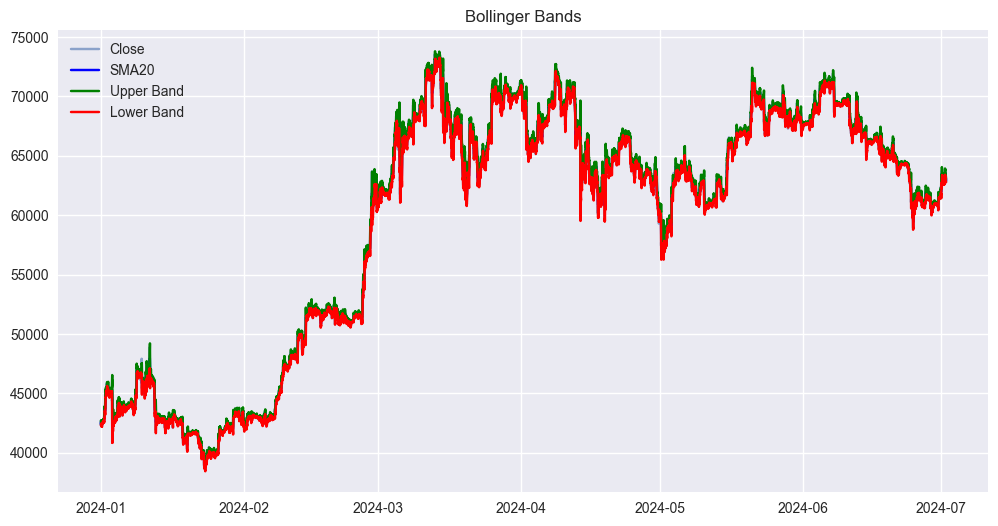

In [98]:
rolling_mean = btc["Close"].rolling(20).mean()
rolling_std = btc["Close"].rolling(20).std()
btc["BB_Upper"] = rolling_mean + 2 * rolling_std
btc["BB_Lower"] = rolling_mean - 2 * rolling_std

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(rolling_mean, label="SMA20", color="blue")
plt.plot(btc["BB_Upper"], label="Upper Band", color="green")
plt.plot(btc["BB_Lower"], label="Lower Band", color="red")
plt.fill_between(btc.index, btc["BB_Lower"], btc["BB_Upper"], color="gray", alpha=0.2)
plt.title("Bollinger Bands")
plt.legend()
plt.show()

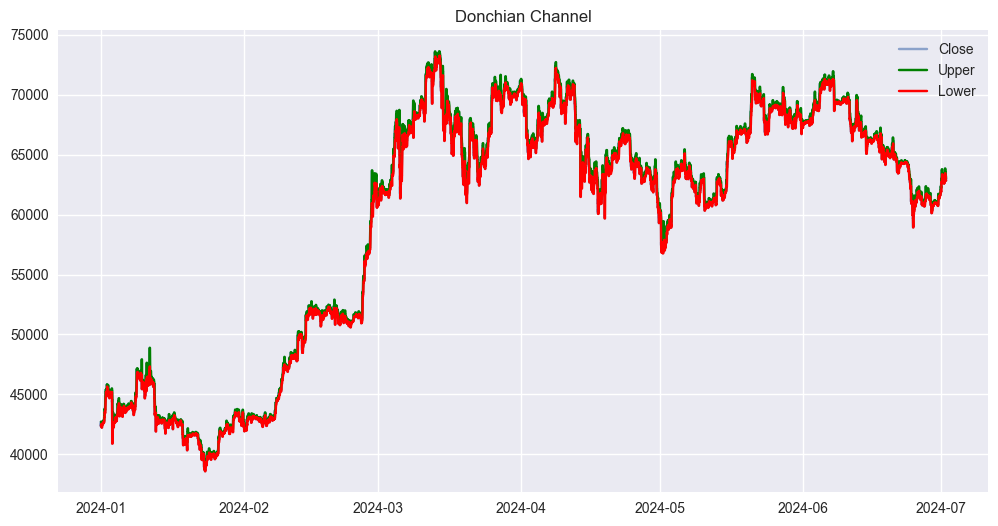

In [99]:
n = 20
btc["Donchian_Upper"] = btc["Close"].rolling(n).max()
btc["Donchian_Lower"] = btc["Close"].rolling(n).min()

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(btc["Donchian_Upper"], label="Upper", color="green")
plt.plot(btc["Donchian_Lower"], label="Lower", color="red")
plt.title("Donchian Channel")
plt.legend()
plt.show()

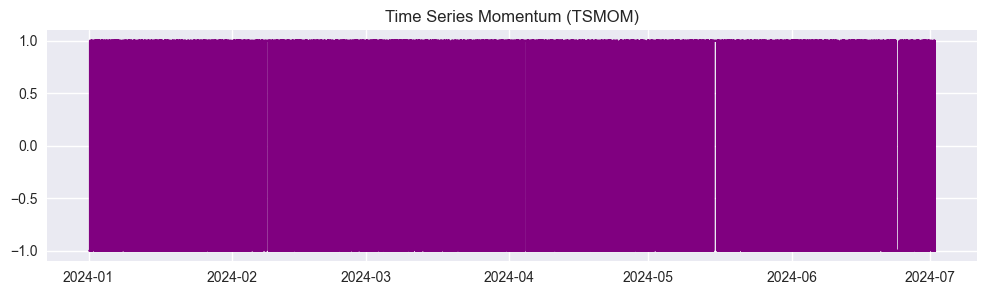

In [100]:
n = 60
btc["TSMOM"] = np.sign(btc["Close"] - btc["Close"].shift(n))

plt.figure(figsize=(12, 3))
plt.plot(btc["TSMOM"], drawstyle="steps-post", color="purple")
plt.title("Time Series Momentum (TSMOM)")
plt.show()

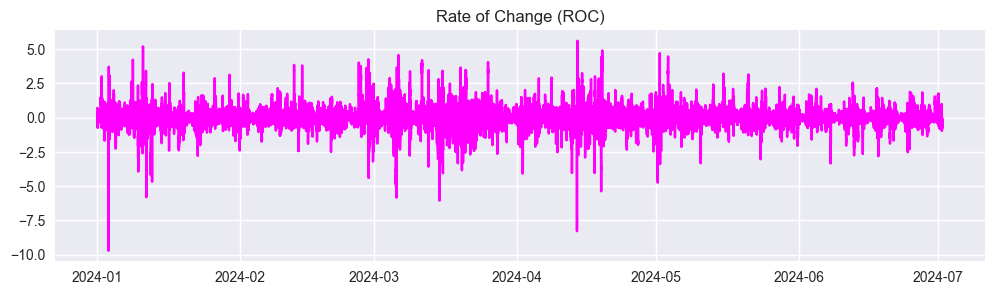

In [101]:
n = 20
btc["ROC"] = (btc["Close"] - btc["Close"].shift(n)) / btc["Close"].shift(n) * 100

plt.figure(figsize=(12, 3))
plt.plot(btc["ROC"], color="fuchsia")
plt.title("Rate of Change (ROC)")
plt.show()

`ema_fast` 和 `ema_slow` 是通过指数移动平均线 (Exponential Moving Average, EMA) 的公式计算的。EMA 是一种加权移动平均线，给最近的数据点赋予更高的权重。其数学公式如下：

### EMA 的公式：
对于时间点 $ t $，EMA 的计算公式为：
$
EMA_t = \alpha \cdot X_t + (1 - \alpha) \cdot EMA_{t-1}
$
其中：
- $ X_t $ 是时间点 $ t $ 的数据值（例如，收盘价 `Close`）。
- $ EMA_{t-1} $ 是前一个时间点的 EMA 值。
- $ \alpha $ 是平滑因子，计算方式为：
$
\alpha = \frac{2}{N + 1}
$
其中 $ N $ 是时间跨度（`span`）。

### `ema_fast` 和 `ema_slow` 的计算：
- `ema_fast` 使用 $ N = 12 $：
$
\alpha_{\text{fast}} = \frac{2}{12 + 1} = \frac{2}{13}
$
$
EMA_{\text{fast}, t} = \alpha_{\text{fast}} \cdot X_t + (1 - \alpha_{\text{fast}}) \cdot EMA_{\text{fast}, t-1}
$

- `ema_slow` 使用 $ N = 26 $：
$
\alpha_{\text{slow}} = \frac{2}{26 + 1} = \frac{2}{27}
$
$
EMA_{\text{slow}, t} = \alpha_{\text{slow}} \cdot X_t + (1 - \alpha_{\text{slow}}) \cdot EMA_{\text{slow}, t-1}
$

### 是否向前计算？
EMA 是一种递归计算方法，当前时间点的 EMA 值依赖于前一个时间点的 EMA 值。因此，EMA 是**向后递归计算**的，即从过去的数据点开始，逐步计算到当前时间点。

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


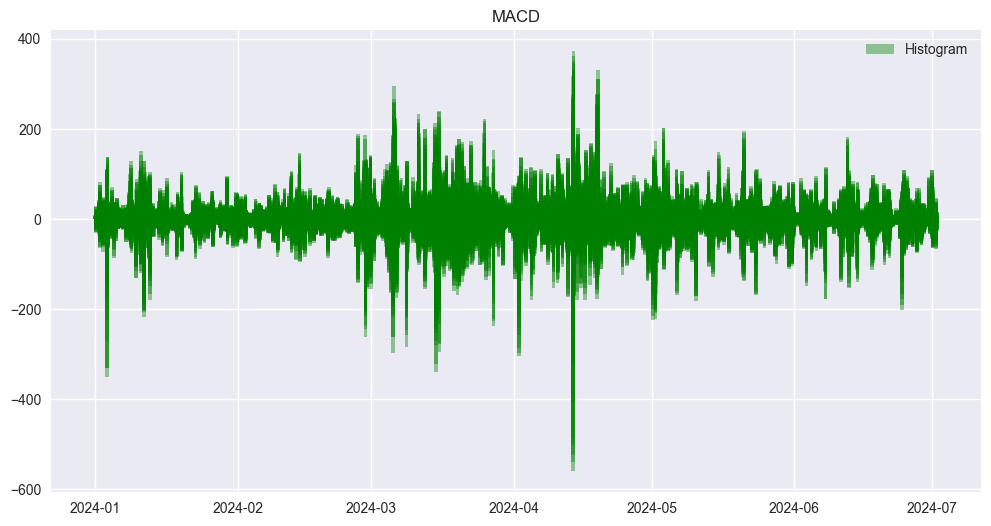

In [102]:
ema_fast = btc["Close"].ewm(span=12, adjust=False).mean()
ema_slow = btc["Close"].ewm(span=26, adjust=False).mean()
btc["MACD"] = ema_fast - ema_slow
btc["Signal"] = btc["MACD"].ewm(span=10, adjust=False).mean()
btc["Hist"] = btc["MACD"] - btc["Signal"]

plt.figure(figsize=(12, 6))
# plt.plot(btc["MACD"], label="MACD", color="blue")
# plt.plot(btc["Signal"], label="Signal", color="orange")
plt.bar(btc.index, btc["Hist"], label="Histogram", color="green", alpha=0.4)
plt.title("MACD")
plt.legend()
plt.show()

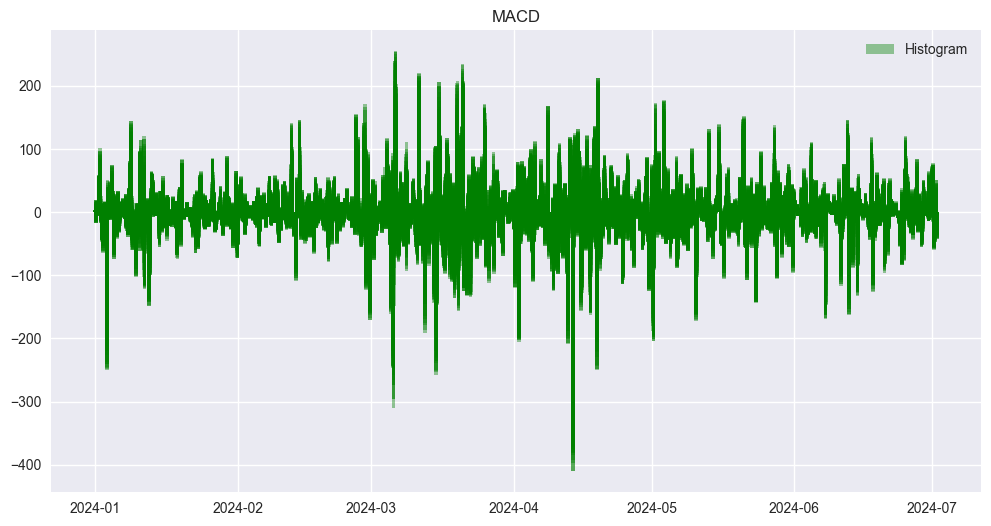

In [103]:
ema_fast = btc["Close"].ewm(span=60, adjust=False).mean()
ema_slow = btc["Close"].ewm(span=360, adjust=False).mean()
btc["MACD"] = ema_fast - ema_slow
btc["Signal"] = btc["MACD"].ewm(span=10, adjust=False).mean()
btc["Hist"] = btc["MACD"] - btc["Signal"]

plt.figure(figsize=(12, 6))
# plt.plot(btc["MACD"], label="MACD", color="blue")
# plt.plot(btc["Signal"], label="Signal", color="orange")
plt.bar(btc.index, btc["Hist"], label="Histogram", color="green", alpha=0.4)
plt.title("MACD")
plt.legend()
plt.show()

In [104]:
btc["Hist"].to_csv("hist.csv")

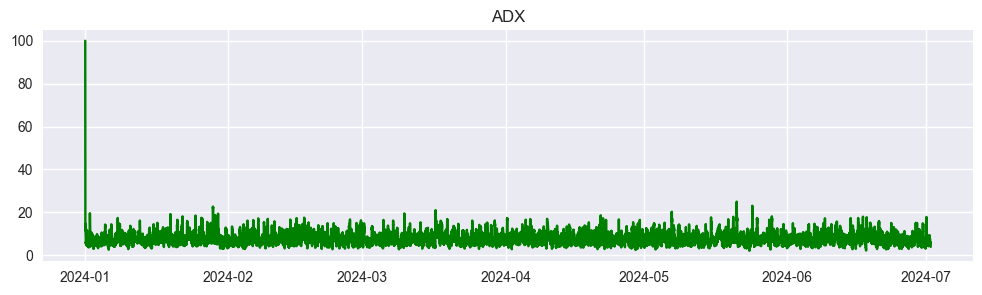

In [105]:
def ADX(df, n=14):
    df["H-L"] = df["Close"].shift(-1) - df["Close"]
    df["H-PC"] = df["Close"].shift(-1) - df["Close"].shift(1)
    df["L-PC"] = df["Close"] - df["Close"].shift(1)

    df["+DM"] = np.where((df["H-L"] > df["L-PC"]) & (df["H-L"] > 0), df["H-L"], 0)
    df["-DM"] = np.where((df["L-PC"] > df["H-L"]) & (df["L-PC"] > 0), df["L-PC"], 0)
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].abs().max(axis=1)

    df["+DI"] = 100 * (
        df["+DM"].ewm(alpha=1 / n).mean() / df["TR"].ewm(alpha=1 / n).mean()
    )
    df["-DI"] = 100 * (
        df["-DM"].ewm(alpha=1 / n).mean() / df["TR"].ewm(alpha=1 / n).mean()
    )
    df["DX"] = (abs(df["+DI"] - df["-DI"]) / (df["+DI"] + df["-DI"])) * 100
    df["ADX"] = df["DX"].ewm(alpha=1 / n).mean()
    return df


btc = ADX(btc.copy(), 14)

plt.figure(figsize=(12, 3))
plt.plot(btc["ADX"], label="ADX", color="green")
plt.title("ADX")
plt.show()

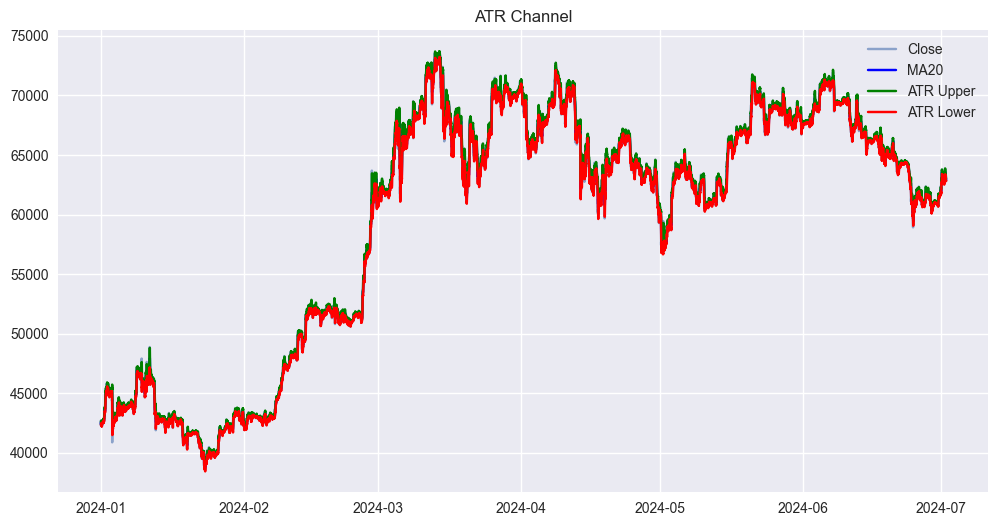

In [106]:
n = 14
btc["H-L"] = btc["Close"].shift(-1) - btc["Close"]
btc["H-PC"] = btc["Close"].shift(-1) - btc["Close"].shift(1)
btc["L-PC"] = btc["Close"] - btc["Close"].shift(1)
btc["TR"] = btc[["H-L", "H-PC", "L-PC"]].abs().max(axis=1)
btc["ATR"] = btc["TR"].rolling(n).mean()

ma = btc["Close"].rolling(20).mean()
btc["ATR_Upper"] = ma + 2 * btc["ATR"]
btc["ATR_Lower"] = ma - 2 * btc["ATR"]

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(ma, label="MA20", color="blue")
plt.plot(btc["ATR_Upper"], label="ATR Upper", color="green")
plt.plot(btc["ATR_Lower"], label="ATR Lower", color="red")
plt.title("ATR Channel")
plt.legend()
plt.show()

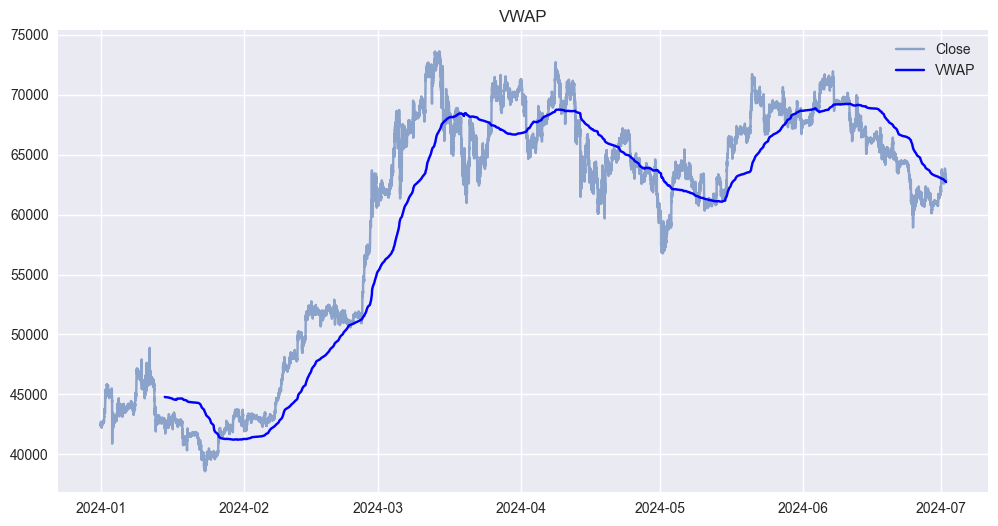

In [107]:
n = 4000
# 设置窗口
cum_vol = btc["Volume"].rolling(window=n).sum()
cum_vol_px = (btc["Close"] * btc["Volume"]).rolling(window=n).sum()
btc["VWAP"] = cum_vol_px / cum_vol

plt.figure(figsize=(12, 6))
plt.plot(btc["Close"], label="Close", alpha=0.6)
plt.plot(btc["VWAP"], label="VWAP", color="blue")
plt.title("VWAP")
plt.legend()
plt.show()

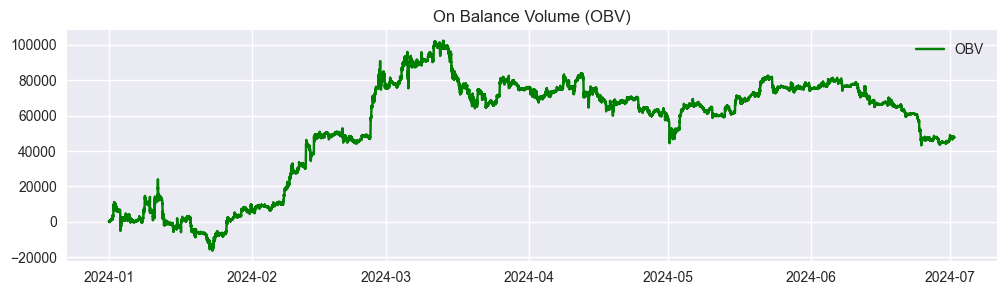

In [108]:
btc["OBV"] = (np.sign(btc["Close"].diff()) * btc["Volume"]).fillna(0).cumsum()

plt.figure(figsize=(12, 3))
plt.plot(btc["OBV"], label="OBV", color="green")
plt.title("On Balance Volume (OBV)")
plt.legend()
plt.show()